===== HASIL EVALUASI =====

Nearest:
MSE: 1151.8095293981482
PSNR: 17.516996935607118
Waktu: 0.012285947799682617

Bilinear:
MSE: 1127.7693636574074
PSNR: 17.608600682527925
Waktu: 0.027312755584716797

Bicubic:
MSE: 1156.1421837962962
PSNR: 17.50069113426161
Waktu: 0.08605337142944336


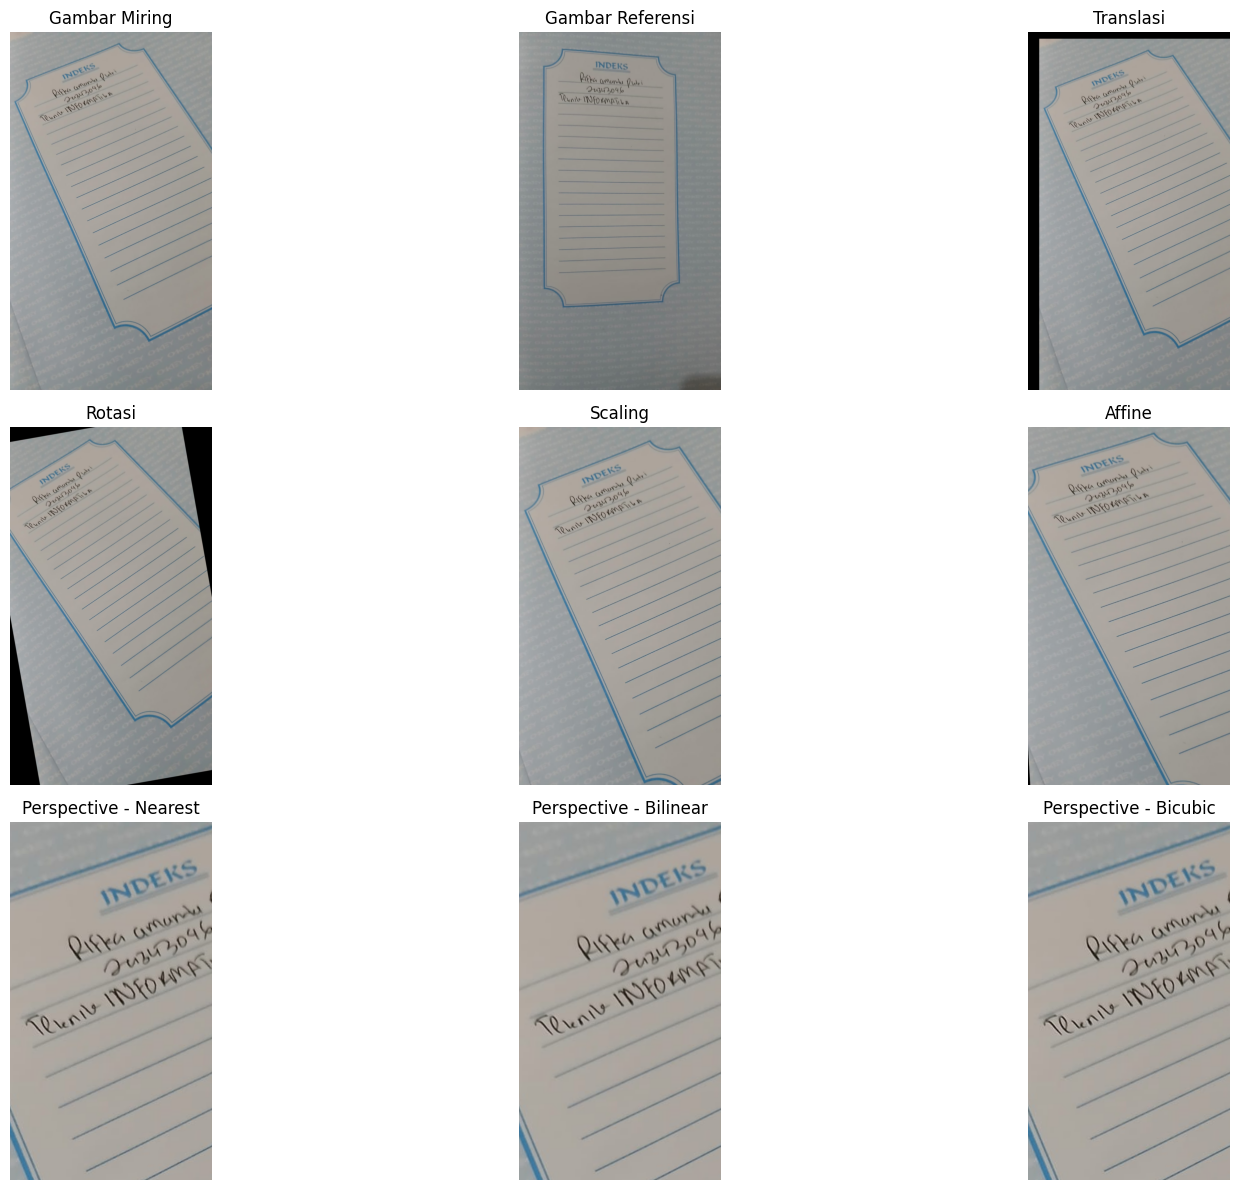

In [3]:
import cv2
import numpy as np
import time
import matplotlib.pyplot as plt

# ==========================================================
# LOAD IMAGE
# ==========================================================
img1 = cv2.imread("miring.jpeg")   # gambar miring
img2 = cv2.imread("lurus.jpeg")    # gambar referensi

if img1 is None or img2 is None:
    print("Error: Gambar tidak ditemukan!")
    exit()

h, w = img2.shape[:2]

img1_rgb = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2_rgb = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

# ==========================================================
# 1️1 TRANSLASI (Homogen Matrix)
# ==========================================================
tx, ty = 50, 30

T = np.array([[1, 0, tx],
              [0, 1, ty]], dtype=np.float32)

translasi = cv2.warpAffine(img1, T, (w, h))

# ==========================================================
# 2 ROTASI (Homogen Matrix)
# ==========================================================
angle = 10
center = (w//2, h//2)

R = cv2.getRotationMatrix2D(center, angle, 1.0)
rotasi = cv2.warpAffine(img1, R, (w, h))

# ==========================================================
# 3️SCALING (Homogen Matrix)
# ==========================================================
S = np.array([[1.2, 0, 0],
              [0, 1.2, 0]], dtype=np.float32)

scaling = cv2.warpAffine(img1, S, (w, h))

# ==========================================================
# 4️ AFFINE TRANSFORM (3 titik)
# ==========================================================
pts1_affine = np.float32([[100,100],
                          [400,100],
                          [100,500]])

pts2_affine = np.float32([[50,50],
                          [450,80],
                          [80,550]])

M_affine = cv2.getAffineTransform(pts1_affine, pts2_affine)
affine = cv2.warpAffine(img1, M_affine, (w, h))

# ==========================================================
# 5️ PERSPEKTIF TRANSFORM (4 titik)
# ==========================================================
pts1 = np.float32([[100,100],
                   [400,80],
                   [120,600],
                   [420,620]])

pts2 = np.float32([[0,0],
                   [w,0],
                   [0,h],
                   [w,h]])

M_persp = cv2.getPerspectiveTransform(pts1, pts2)

# =============================
# INTERPOLASI
# =============================

start = time.time()
nearest = cv2.warpPerspective(img1, M_persp, (w,h), flags=cv2.INTER_NEAREST)
time_nearest = time.time() - start

start = time.time()
linear = cv2.warpPerspective(img1, M_persp, (w,h), flags=cv2.INTER_LINEAR)
time_linear = time.time() - start

start = time.time()
cubic = cv2.warpPerspective(img1, M_persp, (w,h), flags=cv2.INTER_CUBIC)
time_cubic = time.time() - start

# ==========================================================
# EVALUASI MSE & PSNR
# ==========================================================
def evaluate(img_ref, img_test):
    mse = np.mean((img_ref.astype("float") - img_test.astype("float")) ** 2)
    if mse == 0:
        return mse, float("inf")
    psnr = 10 * np.log10((255**2) / mse)
    return mse, psnr

mse_nearest, psnr_nearest = evaluate(img2, nearest)
mse_linear, psnr_linear   = evaluate(img2, linear)
mse_cubic, psnr_cubic     = evaluate(img2, cubic)


print("===== HASIL EVALUASI =====")

print("\nNearest:")
print("MSE:", mse_nearest)
print("PSNR:", psnr_nearest)
print("Waktu:", time_nearest)

print("\nBilinear:")
print("MSE:", mse_linear)
print("PSNR:", psnr_linear)
print("Waktu:", time_linear)

print("\nBicubic:")
print("MSE:", mse_cubic)
print("PSNR:", psnr_cubic)
print("Waktu:", time_cubic)


plt.figure(figsize=(18,12))

plt.subplot(3,3,1)
plt.imshow(img1_rgb)
plt.title("Gambar Miring")
plt.axis("off")

plt.subplot(3,3,2)
plt.imshow(img2_rgb)
plt.title("Gambar Referensi")
plt.axis("off")

plt.subplot(3,3,3)
plt.imshow(cv2.cvtColor(translasi, cv2.COLOR_BGR2RGB))
plt.title("Translasi")
plt.axis("off")

plt.subplot(3,3,4)
plt.imshow(cv2.cvtColor(rotasi, cv2.COLOR_BGR2RGB))
plt.title("Rotasi")
plt.axis("off")

plt.subplot(3,3,5)
plt.imshow(cv2.cvtColor(scaling, cv2.COLOR_BGR2RGB))
plt.title("Scaling")
plt.axis("off")

plt.subplot(3,3,6)
plt.imshow(cv2.cvtColor(affine, cv2.COLOR_BGR2RGB))
plt.title("Affine")
plt.axis("off")

plt.subplot(3,3,7)
plt.imshow(cv2.cvtColor(nearest, cv2.COLOR_BGR2RGB))
plt.title("Perspective - Nearest")
plt.axis("off")

plt.subplot(3,3,8)
plt.imshow(cv2.cvtColor(linear, cv2.COLOR_BGR2RGB))
plt.title("Perspective - Bilinear")
plt.axis("off")

plt.subplot(3,3,9)
plt.imshow(cv2.cvtColor(cubic, cv2.COLOR_BGR2RGB))
plt.title("Perspective - Bicubic")
plt.axis("off")

plt.tight_layout()
plt.show()